## Lab 4d
#### MNIST Classification using LeNet-5 (Deep Learning)
<img src="https://raw.githubusercontent.com/wooihaw/ml_dl_comparison/main/dl_mnist.jpg" width="800" height="400">

In [1]:
# Initialization
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# ------------------------------------------------------------
# 1. Load and preprocess the MNIST dataset
# ------------------------------------------------------------
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# Reshape to (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values (0–255 → 0–1)
X_train /= 255.0
X_test /= 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
# ------------------------------------------------------------
# 2. Define the LeNet-5 model
# ------------------------------------------------------------
model = models.Sequential([
    # Input layer
    layers.Input(shape=(28, 28, 1)),
    # C1: Convolutional layer
    layers.Conv2D(filters=6, kernel_size=(5, 5), activation='relu', padding='same'),
    # S2: Average pooling
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # C3: Convolutional layer
    layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu'),
    # S4: Average pooling
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Flatten before entering fully connected layers
    layers.Flatten(),

    # C5: Fully connected layer
    layers.Dense(120, activation='relu'),
    # F6: Fully connected layer
    layers.Dense(84, activation='relu'),
    # Output layer
    layers.Dense(10, activation='softmax')
])

In [5]:
# ------------------------------------------------------------
# 3. Compile the model
# ------------------------------------------------------------
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ------------------------------------------------------------
# 4. Train the model
# ------------------------------------------------------------
# Use EarlyStopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=128,
                    validation_split=0.1,
                    callbacks=[early_stop],
                    verbose=2)

Epoch 1/15
422/422 - 8s - 20ms/step - accuracy: 0.9017 - loss: 0.3307 - val_accuracy: 0.9730 - val_loss: 0.0989
Epoch 2/15
422/422 - 2s - 4ms/step - accuracy: 0.9738 - loss: 0.0859 - val_accuracy: 0.9813 - val_loss: 0.0639
Epoch 3/15
422/422 - 2s - 4ms/step - accuracy: 0.9808 - loss: 0.0602 - val_accuracy: 0.9845 - val_loss: 0.0553
Epoch 4/15
422/422 - 2s - 4ms/step - accuracy: 0.9846 - loss: 0.0478 - val_accuracy: 0.9843 - val_loss: 0.0518
Epoch 5/15
422/422 - 2s - 4ms/step - accuracy: 0.9874 - loss: 0.0397 - val_accuracy: 0.9872 - val_loss: 0.0457
Epoch 6/15
422/422 - 2s - 4ms/step - accuracy: 0.9894 - loss: 0.0336 - val_accuracy: 0.9875 - val_loss: 0.0478
Epoch 7/15
422/422 - 2s - 4ms/step - accuracy: 0.9905 - loss: 0.0295 - val_accuracy: 0.9887 - val_loss: 0.0435
Epoch 8/15
422/422 - 2s - 4ms/step - accuracy: 0.9925 - loss: 0.0243 - val_accuracy: 0.9883 - val_loss: 0.0418
Epoch 9/15
422/422 - 2s - 4ms/step - accuracy: 0.9929 - loss: 0.0210 - val_accuracy: 0.9877 - val_loss: 0.0492



Test Accuracy: 0.9890


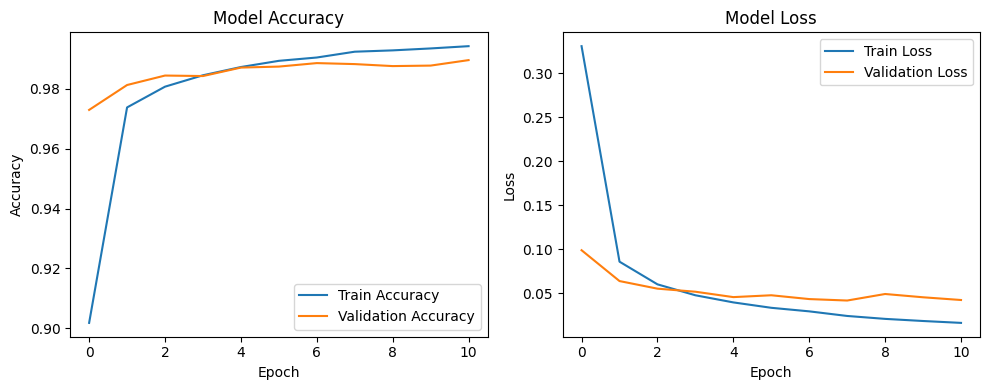

In [7]:
# ------------------------------------------------------------
# 5. Evaluate the model
# ------------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# ------------------------------------------------------------
# 6. Visualize training history
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



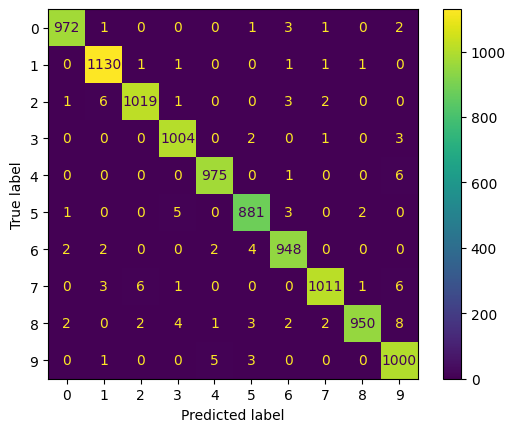

In [8]:
# ------------------------------------------------------------
# Confusion Matrix for CNN Model
# ------------------------------------------------------------
# Convert probabilities to predicted classes
y_pred = model.predict(X_test).argmax(axis=1)

# Convert one-hot test labels to integers
y_true = y_test.argmax(axis=1)

# To do: Print classification report
print(classification_report(y_true, y_pred))

# To do: Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
